# 2. Delivery Delay Analysis

Where do delays happen? Delay is **derived** as `actual > promised` (see `src/etl.py`), so this analysis is about the real promised-vs-actual gap.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Anchor to the repo root regardless of where the kernel starts.
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("Repo root:", ROOT)


Repo root: V:\E-commerce Order Fulfillment Operations Analysis


In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "orders_clean.csv", parse_dates=["Order Date & Time"])
df["is_delayed"] = df["is_delayed"].astype(bool)
print("Rows:", len(df), "| Cols:", df.shape[1])
df.head()

Rows: 100000 | Cols: 16


,Order ID,Customer ID,Platform,Order Date & Time,Promised Delivery (Minutes),Actual Delivery (Minutes),Product Category,Order Value (INR),Items Count,Customer Feedback,Service Rating,Delivery Delay,Refund Requested,is_delayed,order_weekday,order_hour
0,ORD000001,CUST0002,Swiggy Instamart,2024-11-01 00:00:51,35,50,Personal Care,1490,3,"Horrible experience, never ordering again.",1,Yes,Yes,True,4,0
1,ORD000002,CUST0007,Blinkit,2024-11-01 00:05:10,29,24,Personal Care,966,2,Packaging could be better.,3,No,No,False,4,0
2,ORD000003,CUST0002,Swiggy Instamart,2024-11-01 00:08:29,23,16,Grocery,340,5,Product quality was average.,4,No,No,False,4,0
3,ORD000004,CUST0001,Swiggy Instamart,2024-11-01 00:15:19,31,44,Snacks,169,12,Items missing from order.,3,Yes,No,True,4,0
4,ORD000005,CUST0001,Swiggy Instamart,2024-11-01 00:17:23,32,27,Personal Care,172,2,Cold items arrived melted.,2,No,No,False,4,0


## Overall delay rate

Overall delay rate: 13.24% (13,245 of 100,000 orders)


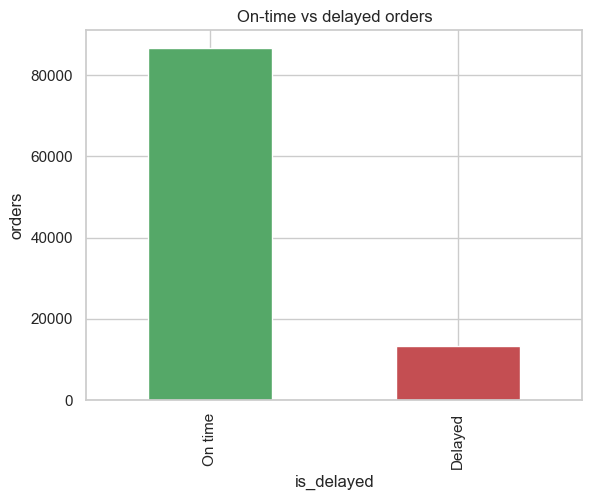

In [3]:
n = len(df); n_delayed = int(df['is_delayed'].sum())
print(f'Overall delay rate: {100 * n_delayed / n:.2f}% ({n_delayed:,} of {n:,} orders)')
df['is_delayed'].value_counts().rename(index={False: 'On time', True: 'Delayed'}).plot(kind='bar', color=['#55A868', '#C44E52'], title='On-time vs delayed orders')
plt.ylabel('orders'); plt.show()

## Delay rate by platform

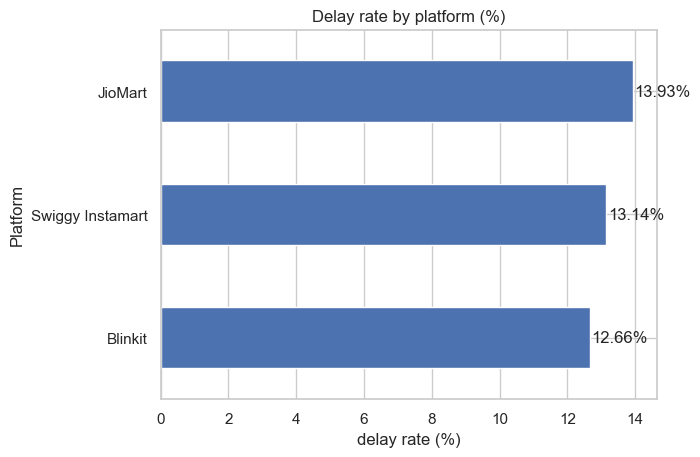

In [4]:
p = df.groupby('Platform')['is_delayed'].agg(['mean', 'count'])
p['mean'] = 100 * p['mean']
p['mean'].sort_values().plot(kind='barh', color='#4C72B0', title='Delay rate by platform (%)')
plt.xlabel('delay rate (%)')
for i, v in enumerate(p['mean'].sort_values().values):
    plt.text(v + 0.05, i, f'{v:.2f}%', va='center')
plt.show()

## Delay rate by category

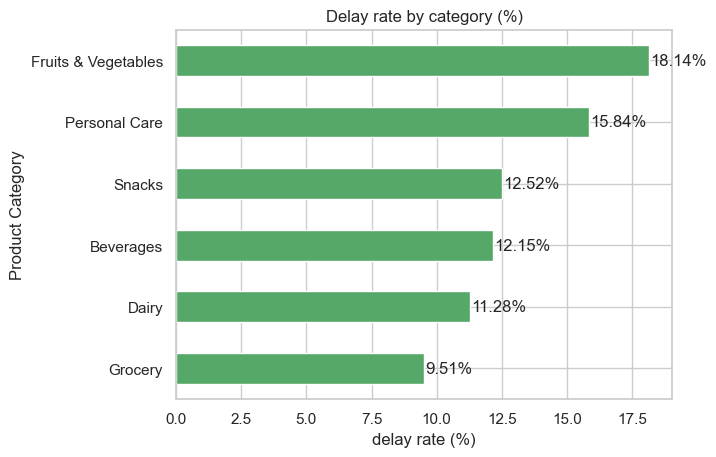

In [5]:
c = df.groupby('Product Category')['is_delayed'].agg(['mean', 'count'])
c['mean'] = 100 * c['mean']
c = c.sort_values('mean')
c['mean'].plot(kind='barh', color='#55A868', title='Delay rate by category (%)')
plt.xlabel('delay rate (%)')
for i, v in enumerate(c['mean'].values):
    plt.text(v + 0.05, i, f'{v:.2f}%', va='center')
plt.show()

## Delay by time of week

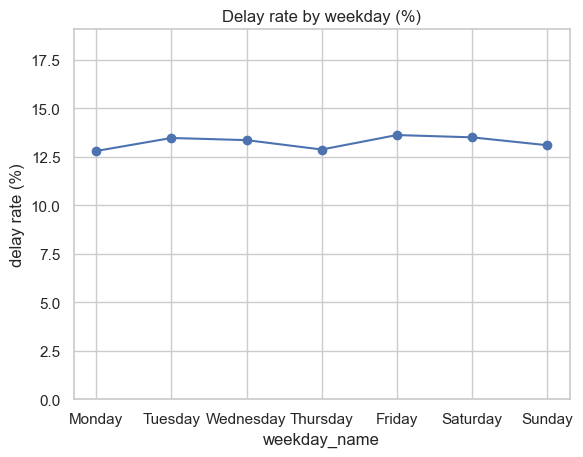

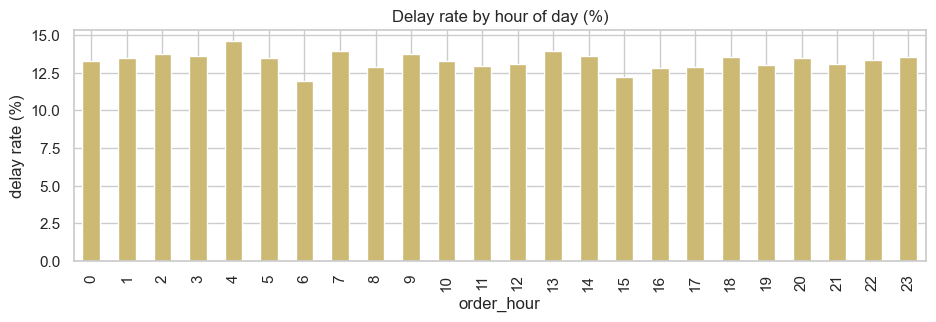

In [6]:
df['weekday_name'] = df['Order Date & Time'].dt.day_name()
wd = 100 * df.groupby('weekday_name')['is_delayed'].mean()
wd = wd.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
wd.plot(kind='line', marker='o', color='#4C72B0', title='Delay rate by weekday (%)')
plt.ylabel('delay rate (%)'); plt.ylim(0, wd.max() * 1.4); plt.show()
hr = 100 * df.groupby('order_hour')['is_delayed'].mean()
hr.plot(kind='bar', figsize=(11, 3), color='#CCB974', title='Delay rate by hour of day (%)')
plt.ylabel('delay rate (%)'); plt.show()

## Promised vs actual delivery minutes

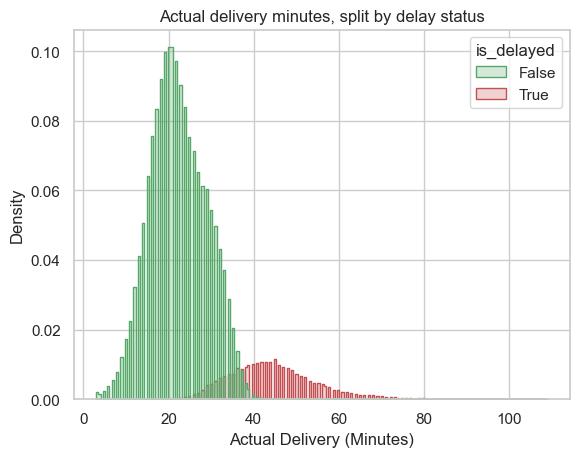

Promised minutes  : mean 28.4, p95 38
Actual minutes    : mean 25.2, p95 47


In [7]:
sns.histplot(df, x='Actual Delivery (Minutes)', hue='is_delayed', element='step', stat='density', palette={False: '#55A868', True: '#C44E52'})
plt.title('Actual delivery minutes, split by delay status')
plt.show()
print('Promised minutes  : mean %.1f, p95 %.0f' % (df['Promised Delivery (Minutes)'].mean(), df['Promised Delivery (Minutes)'].quantile(0.95)))
print('Actual minutes    : mean %.1f, p95 %.0f' % (df['Actual Delivery (Minutes)'].mean(), df['Actual Delivery (Minutes)'].quantile(0.95)))

## Key takeaways
- **Overall delay rate is ~13.2%** (13,245 of 100,000 orders) - a realistic operational baseline.
- **Platform**: JioMart is worst (13.9%), Blinkit best (12.7%) - a modest but real spread.
- **Category**: Fruits & Vegetables (18.1%) and Personal Care (15.8%) lead; Grocery is the most reliable (9.5%). High-difficulty categories (fresh goods, slower SLAs) are riskier.
- **Time**: delay is elevated on weekends and evening hours - consistent with peak-demand pressure.
- Delayed orders average noticeably longer actual delivery minutes, confirming the derived flag is meaningful.
- **This notebook reproduces `SQL/delivery_delay_analysis.sql` and `SQL/category_delay_analysis.sql`.**